In [1]:
# I am importing pandas to load and work with the cleaned CSV data
import pandas as pd

# I am importing matplotlib and seaborn for visualizing the data
import matplotlib.pyplot as plt
import seaborn as sns

# This line loads the clean data created by our ETL pipeline
df = pd.read_csv("../data/processed/clean_data.csv")

# Display first 5 rows just to check everything is correct
df.head()


,vehicle_id,speed,battery_temp,motor_torque,energy_consumption,outside_temp,timestamp,temp_difference
0,EV001,27.93,44.01,184.60,8.40,18.79,2025-12-05 18:28:00,25.22
1,EV001,81.85,26.24,113.33,14.20,34.56,2025-12-05 18:28:00,-8.32
2,EV001,88.92,28.47,299.36,11.05,28.52,2025-12-05 18:28:00,-0.05
3,EV001,49.22,36.92,285.90,12.54,25.44,2025-12-05 18:28:00,11.48
4,EV001,35.93,42.11,290.02,10.73,12.33,2025-12-05 18:28:00,29.78


In [2]:
# I am checking the overall structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   vehicle_id          200 non-null    object 
 1   speed               200 non-null    float64
 2   battery_temp        200 non-null    float64
 3   motor_torque        200 non-null    float64
 4   energy_consumption  200 non-null    float64
 5   outside_temp        200 non-null    float64
 6   timestamp           200 non-null    object 
 7   temp_difference     200 non-null    float64
dtypes: float64(6), object(2)
memory usage: 12.6+ KB


In [3]:
# This gives me mean, min, max, etc. for all numeric columns
df.describe()


,speed,battery_temp,motor_torque,energy_consumption,outside_temp,temp_difference
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,58.941350,35.004800,198.745050,13.465700,23.145200,11.859600
std,23.026957,6.023796,57.595887,3.507568,7.862609,10.092529
min,20.050000,25.170000,100.340000,8.040000,10.300000,-8.530000
25%,38.410000,29.807500,150.867500,10.100000,16.332500,4.107500
50%,59.255000,34.970000,197.430000,13.500000,23.590000,11.775000
75%,80.105000,40.500000,249.747500,16.240000,30.470000,19.045000
max,99.840000,44.960000,299.360000,19.880000,34.990000,34.650000


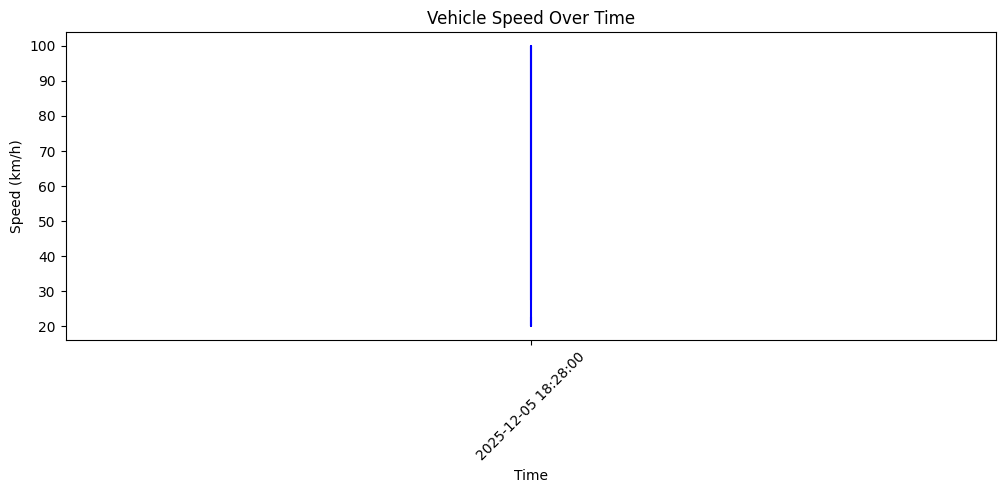

In [4]:
# I want to see how the vehicle's speed changes over time
plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['speed'], color="blue")
plt.title("Vehicle Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Speed (km/h)")
plt.xticks(rotation=45)
plt.show()


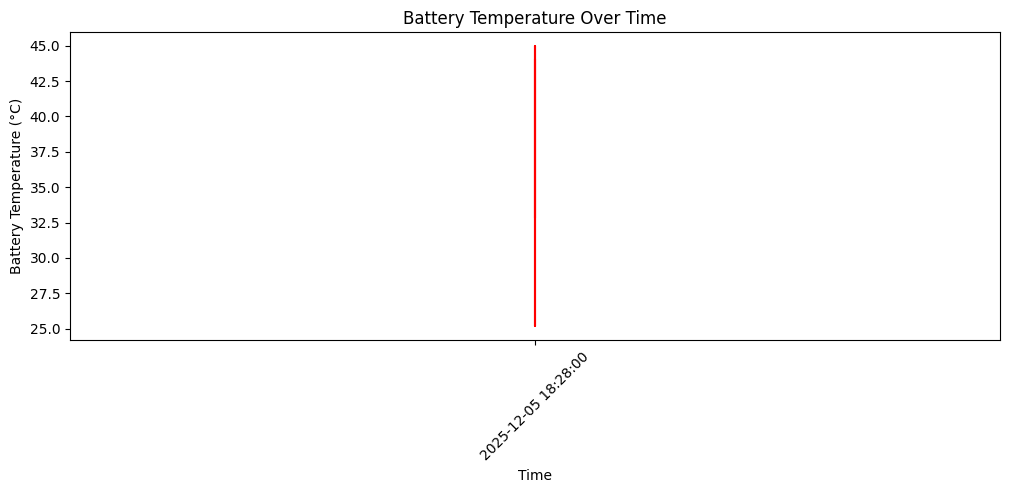

In [5]:
# This graph helps me understand battery temperature patterns
plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['battery_temp'], color="red")
plt.title("Battery Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Battery Temperature (°C)")
plt.xticks(rotation=45)
plt.show()


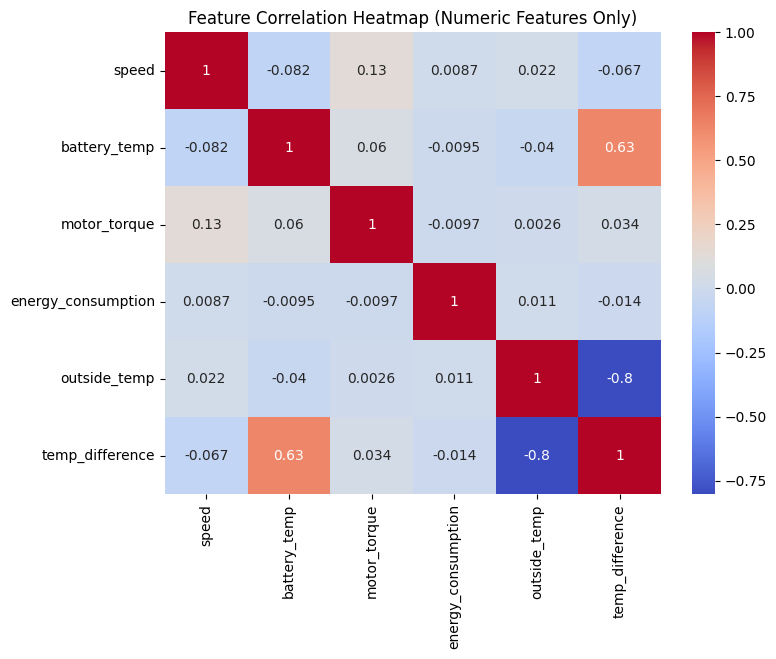

In [7]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Numeric Features Only)")
plt.show()

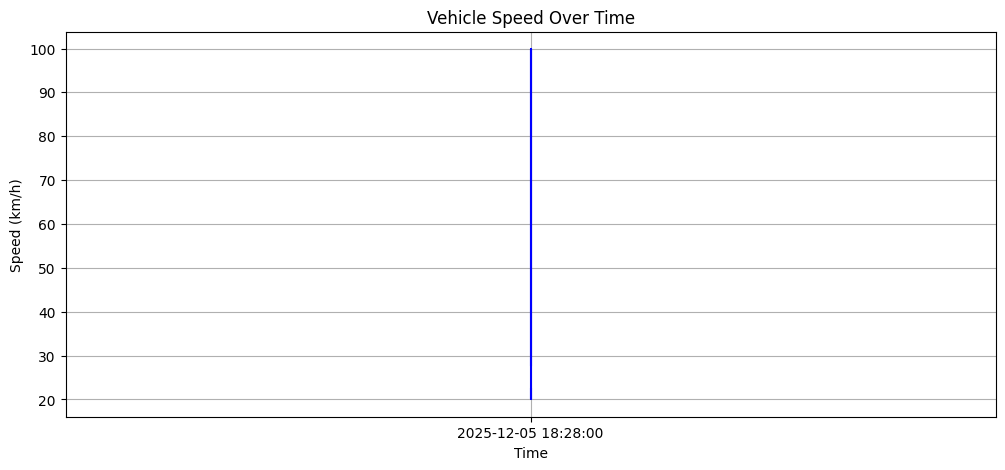

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['speed'], color='blue')
plt.title("Vehicle Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Speed (km/h)")
plt.grid(True)
plt.show()

In [12]:
df.columns


Index(['vehicle_id', 'speed', 'battery_temp', 'motor_torque',
       'energy_consumption', 'outside_temp', 'timestamp', 'temp_difference'],
      dtype='object')

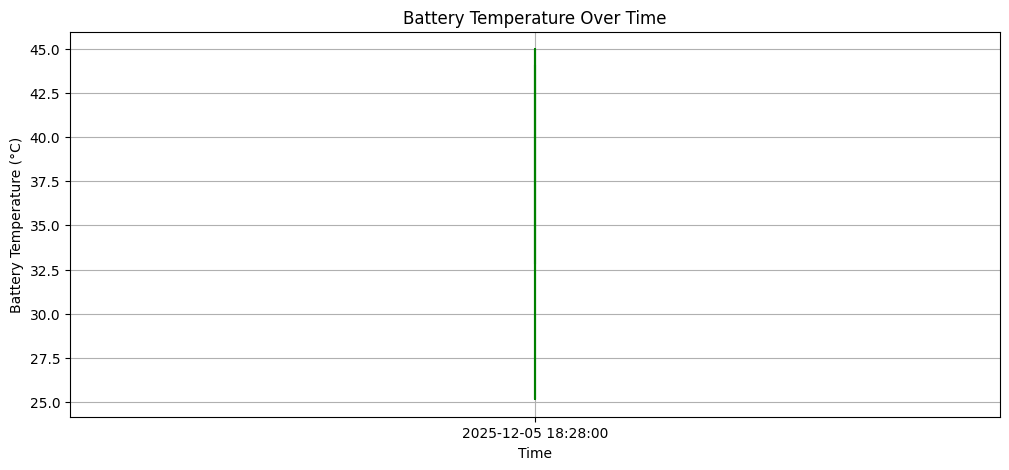

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['battery_temp'], color='green')
plt.title("Battery Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Battery Temperature (°C)")
plt.grid(True)
plt.show()


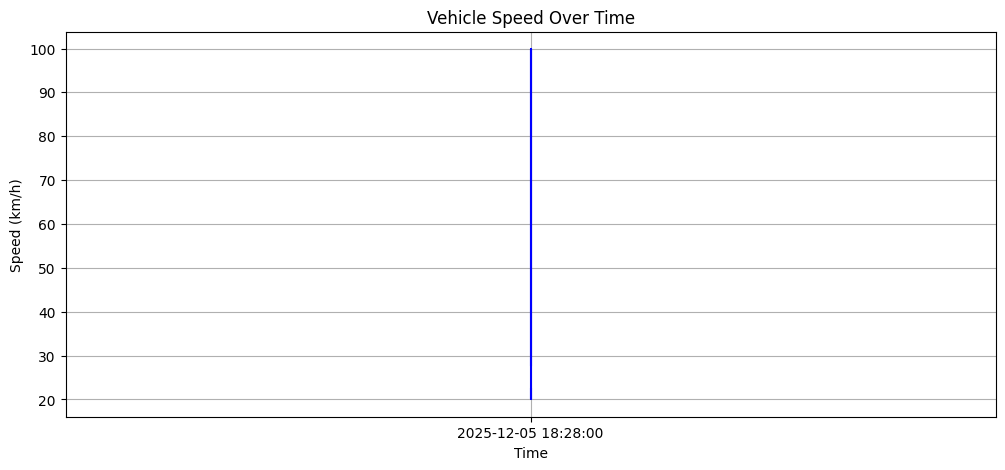

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['speed'], color='blue')
plt.title("Vehicle Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Speed (km/h)")
plt.grid(True)
plt.show()

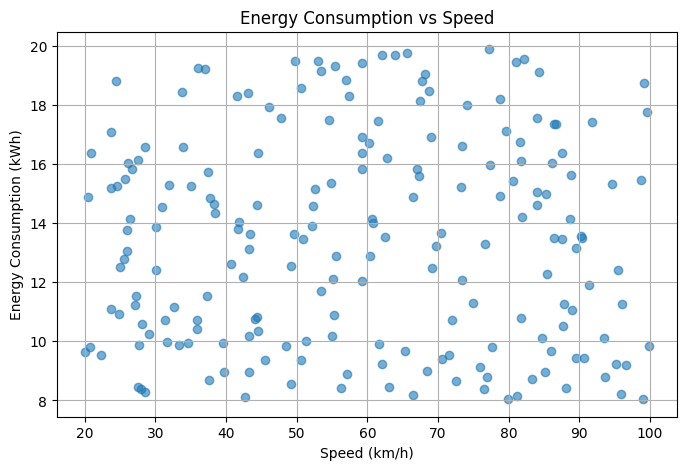

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['speed'], df['energy_consumption'], alpha=0.6)
plt.title("Energy Consumption vs Speed")
plt.xlabel("Speed (km/h)")
plt.ylabel("Energy Consumption (kWh)")
plt.grid(True)
plt.show()


In [17]:
import sklearn
sklearn.__version__


'1.7.2'

In [18]:
from sklearn.ensemble import IsolationForest

features = df[['speed', 'battery_temp', 'motor_torque', 'energy_consumption']]
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(features)

df['anomaly'] = model.predict(features)
df['anomaly'] = df['anomaly'].map({1: 'normal', -1: 'anomaly'})
df.head()


,vehicle_id,speed,battery_temp,motor_torque,energy_consumption,outside_temp,timestamp,temp_difference,anomaly
0,EV001,27.93,44.01,184.60,8.40,18.79,2025-12-05 18:28:00,25.22,normal
1,EV001,81.85,26.24,113.33,14.20,34.56,2025-12-05 18:28:00,-8.32,normal
2,EV001,88.92,28.47,299.36,11.05,28.52,2025-12-05 18:28:00,-0.05,normal
3,EV001,49.22,36.92,285.90,12.54,25.44,2025-12-05 18:28:00,11.48,normal
4,EV001,35.93,42.11,290.02,10.73,12.33,2025-12-05 18:28:00,29.78,normal


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# We create a copy of df
forecast_df = df.copy()

# Target variable: battery_temp shifted - predicting the next reading
forecast_df['future_battery_temp'] = forecast_df['battery_temp'].shift(-1)

# Remove last row (because shift creates a NaN)
forecast_df = forecast_df.dropna()

# Select features (X)
X = forecast_df[['speed', 'motor_torque', 'energy_consumption', 'outside_temp', 'battery_temp']]

# Target (y)
y = forecast_df['future_battery_temp']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.head(), y.head()


(   speed  motor_torque  energy_consumption  outside_temp  battery_temp
 0  27.93        184.60                8.40         18.79         44.01
 1  81.85        113.33               14.20         34.56         26.24
 2  88.92        299.36               11.05         28.52         28.47
 3  49.22        285.90               12.54         25.44         36.92
 4  35.93        290.02               10.73         12.33         42.11,
 0    26.24
 1    28.47
 2    36.92
 3    42.11
 4    26.26
 Name: future_battery_temp, dtype: float64)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")
print("Model Coefficients:", model.coef_)


Model training complete!
Model Coefficients: [-0.02252068  0.01521211  0.03709875  0.13463125 -0.17238935]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)


MAE: 5.218585907017877
MSE: 39.76409791830501


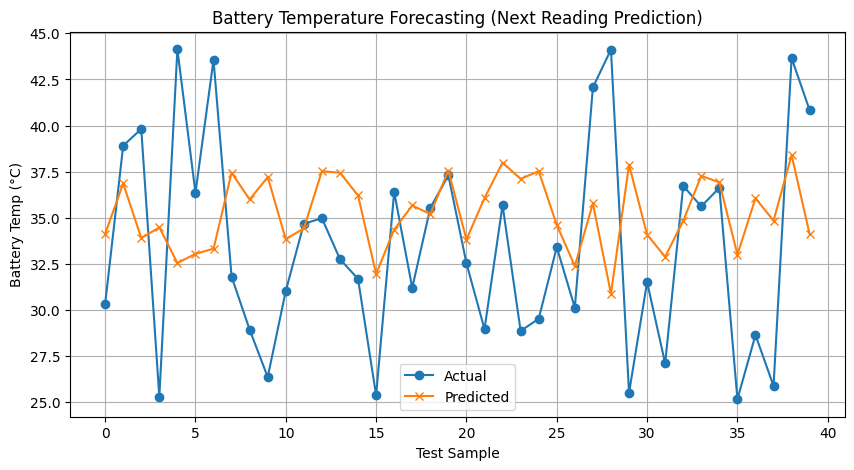

In [22]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred[:50], label="Predicted", marker='x')
plt.title("Battery Temperature Forecasting (Next Reading Prediction)")
plt.xlabel("Test Sample")
plt.ylabel("Battery Temp (°C)")
plt.legend()
plt.grid(True)
plt.show()
